# Homework 2 - Regression and Classification Error Analysis

this notebook analyzes regression and classification models using the Seoul bike sharing dataset

the main regression target is rented bike count

for classification a binary high demand target will be created later

all model evaluation will use k fold cross validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from scipy.stats import skew, kurtosis

In [2]:
# find the data file

file_name = "SeoulBikeData.csv"

possible_paths = [Path("data") / file_name,Path("..") / "data" / file_name]

possible_paths.extend(Path.cwd().glob(f"*/data/{file_name}"))

file_path = next((path for path in possible_paths if path.exists()),None)

if file_path is None:raise FileNotFoundError("SeoulBikeData.csv was not found inside a data folder")

bike_data = pd.read_csv(file_path,encoding="cp1252")

bike_data.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [3]:
# rename columns to make them easier to use

bike_data.columns = [
    "date",
    "rented_count",
    "hour",
    "temperature",
    "humidity",
    "wind_speed",
    "visibility",
    "dew_point_temp",
    "solar_radiation",
    "rainfall",
    "snowfall",
    "season",
    "holiday",
    "functioning_day"]

bike_data["date"] = pd.to_datetime(bike_data["date"],format="%d/%m/%Y")

bike_data.head()

,date,rented_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temp,solar_radiation,rainfall,snowfall,season,holiday,functioning_day
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


## Cross Validation Setup

I will use 5 fold cross validation

The dataset contains 8760 observations so each fold still contains enough data for training and testing

Using 5 folds gives a good balance between computation time and reliable model evaluation

Using more folds could reduce bias slightly but would also require more model training

In [4]:
kfold = KFold(n_splits=5,shuffle=False)
# choose features and target

feature_columns = [
    "hour",
    "temperature",
    "humidity",
    "wind_speed",
    "visibility",
    "dew_point_temp",
    "solar_radiation",
    "rainfall",
    "snowfall",
    "season",
    "holiday",
    "functioning_day"
]

X = bike_data[feature_columns]
y = bike_data["rented_count"]

X.head()

,hour,temperature,humidity,wind_speed,visibility,dew_point_temp,solar_radiation,rainfall,snowfall,season,holiday,functioning_day
0,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


## 2 regression models

in this section i will compare three regression models

all models will use the same features and the same cross validation setup

In [5]:
# split numerical and categorical features

numerical_features = [
    "hour",
    "temperature",
    "humidity",
    "wind_speed",
    "visibility",
    "dew_point_temp",
    "solar_radiation",
    "rainfall",
    "snowfall"]

categorical_features = [
    "season",
    "holiday",
    "functioning_day"]

# prepare the features for the models

preprocessor = ColumnTransformer(transformers=[("num",StandardScaler(),numerical_features),("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)]
)

In [6]:
# create the regression models

linear_model = Pipeline(steps=[("preprocessor", preprocessor),("model", LinearRegression())])

tree_model = Pipeline(steps=[("preprocessor", preprocessor),("model",DecisionTreeRegressor(random_state=42))])

forest_model = Pipeline(steps=[("preprocessor", preprocessor),("model",RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1))])

the linear regression model will be used as the baseline

the decision tree can capture non linear patterns

the random forest combines many trees and may reduce prediction error

In [7]:
# get cross validated predictions

linear_predictions = cross_val_predict(linear_model,X,y,cv=kfold)

tree_predictions = cross_val_predict(tree_model,X,y,cv=kfold)

forest_predictions = cross_val_predict(forest_model,X,y,cv=kfold)

In [8]:
# calculate model performance

model_results = []

models_predictions = {"linear regression": linear_predictions,"decision tree": tree_predictions,"random forest": forest_predictions}

for model_name, predictions in models_predictions.items():

    mse = mean_squared_error(y,predictions)

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(y,predictions)

    r2 = r2_score(y,predictions)

    model_results.append({"model": model_name,"mae": mae,"mse": mse,"rmse": rmse,"r2": r2})

model_results_df = pd.DataFrame(model_results)

model_results_df.round(3)

,model,mae,mse,rmse,r2
0,linear regression,395.450,263810.830,513.625,0.366
1,decision tree,257.164,156969.633,396.194,0.623
2,random forest,223.523,110089.819,331.798,0.735


the models will be compared using mae mse rmse and r2

lower mae mse and rmse values are better

a higher r2 value is better

## 1.1 residual analysis

in this section i will analyze the prediction errors of the random forest model

the residual is the difference between the real value and the predicted value

In [9]:
# calculate residuals
residuals = y - forest_predictions
absolute_errors = np.abs(residuals)

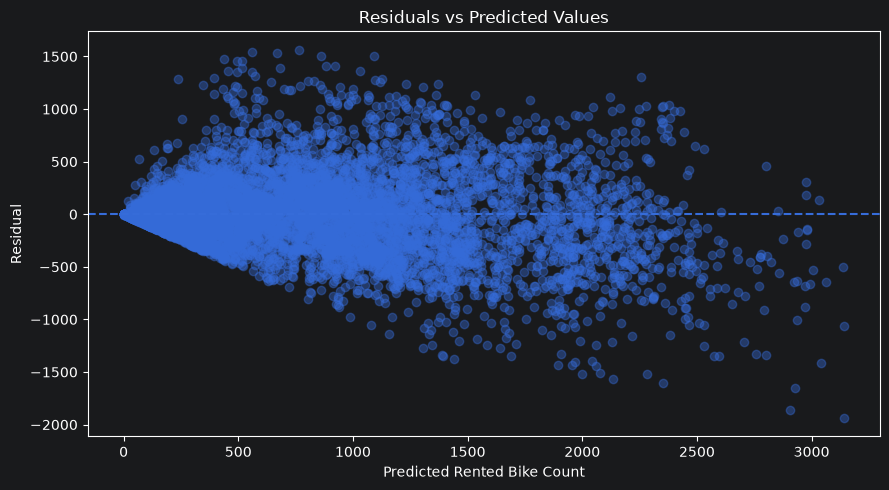

In [10]:
# plot residuals against predicted values

plt.figure(figsize=(9, 5))

plt.scatter(forest_predictions,residuals,alpha=0.4)

plt.axhline(y=0,linestyle="--")

plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Rented Bike Count")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

most residuals are around zero but the spread becomes larger for higher predicted values

this may suggest that the error is not completely constant across all prediction levels

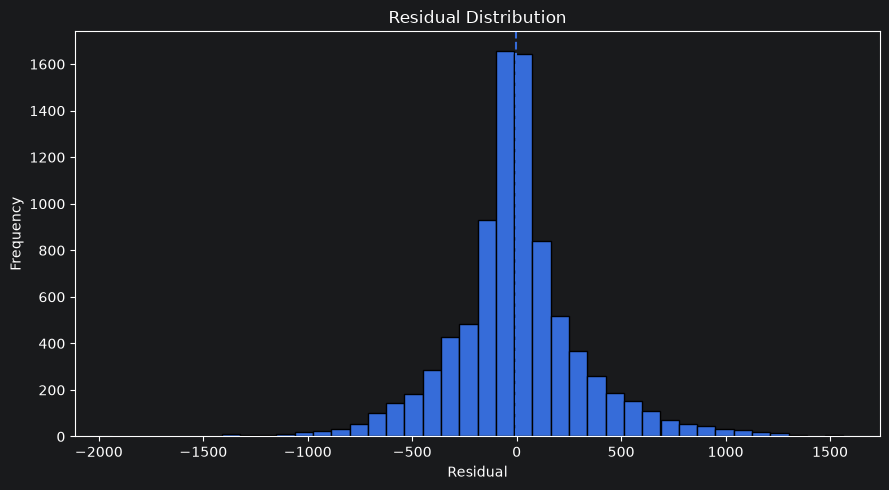

In [11]:
# show residual distribution

plt.figure(figsize=(9, 5))

plt.hist(residuals,bins=40,edgecolor="black")

plt.axvline(residuals.mean(),linestyle="--")

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

the residual distribution is centered close to zero

there are also some large positive and negative errors

this suggests that most predictions are reasonable but some observations are harder for the model

In [12]:
# check residual center
print("mean residual:", round(residuals.mean(), 2))
print("median residual:", round(np.median(residuals), 2))

mean residual: -4.02
median residual: -12.61


a mean residual close to zero suggests that the model does not have a strong overall prediction bias

### answers to the residual analysis questions

the residuals are centered close to zero so the model does not show a strong overall bias

there is a visible pattern in the residuals because the spread becomes wider for larger predicted values

there is evidence of heteroscedasticity since the variance of the errors increases when predicted demand increases

high demand observations seem more likely to have large errors because bike demand can change more strongly during busy hours and conditions

## 1.2 error as a function of features
in this section i will check how the prediction errors change with some of the main features

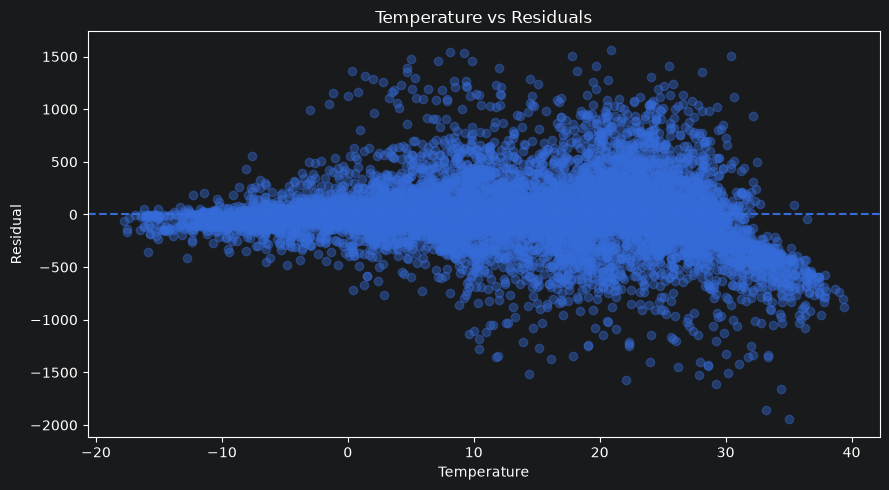

In [13]:
# plot temperature against residuals
plt.figure(figsize=(9, 5))

plt.scatter(bike_data["temperature"],residuals,alpha=0.4)

plt.axhline(y=0,linestyle="--")

plt.title("Temperature vs Residuals")
plt.xlabel("Temperature")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

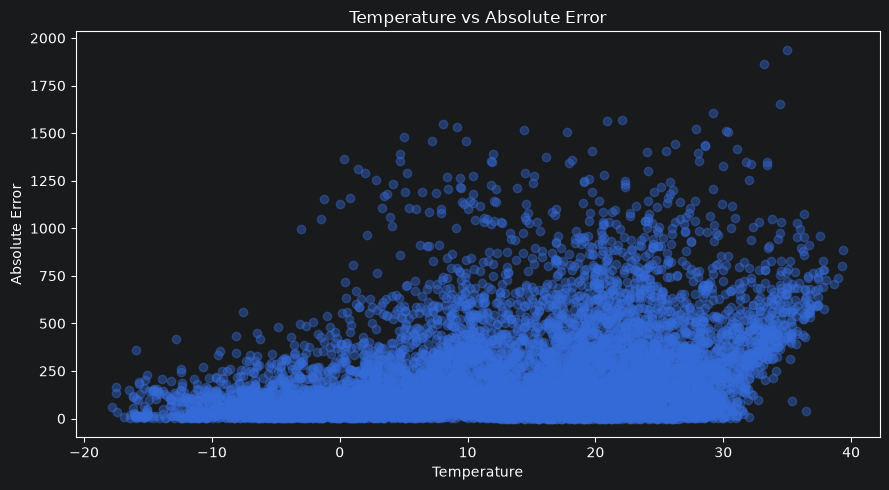

In [14]:
# plot temperature against absolute error
plt.figure(figsize=(9, 5))

plt.scatter(bike_data["temperature"],absolute_errors,alpha=0.4)

plt.title("Temperature vs Absolute Error")
plt.xlabel("Temperature")
plt.ylabel("Absolute Error")
plt.tight_layout()
plt.show()

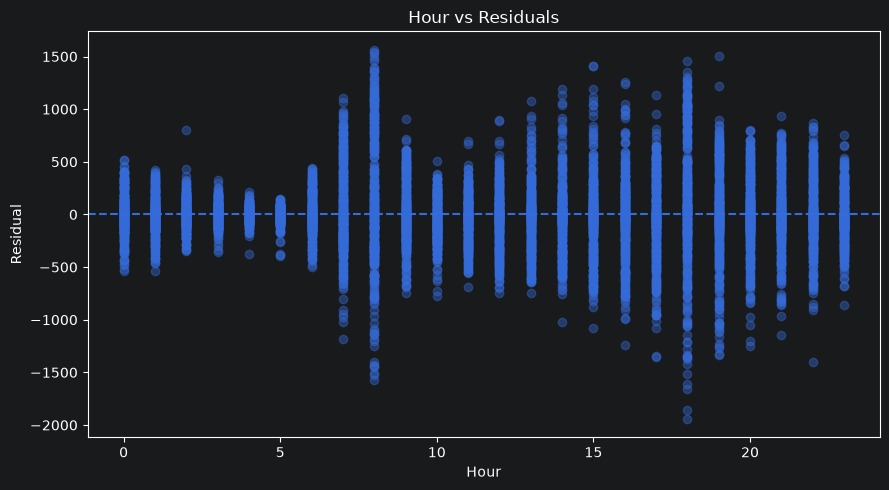

In [15]:
# plot hour against residuals
plt.figure(figsize=(9, 5))

plt.scatter(bike_data["hour"],residuals,alpha=0.4)

plt.axhline(y=0,linestyle="--")

plt.title("Hour vs Residuals")
plt.xlabel("Hour")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

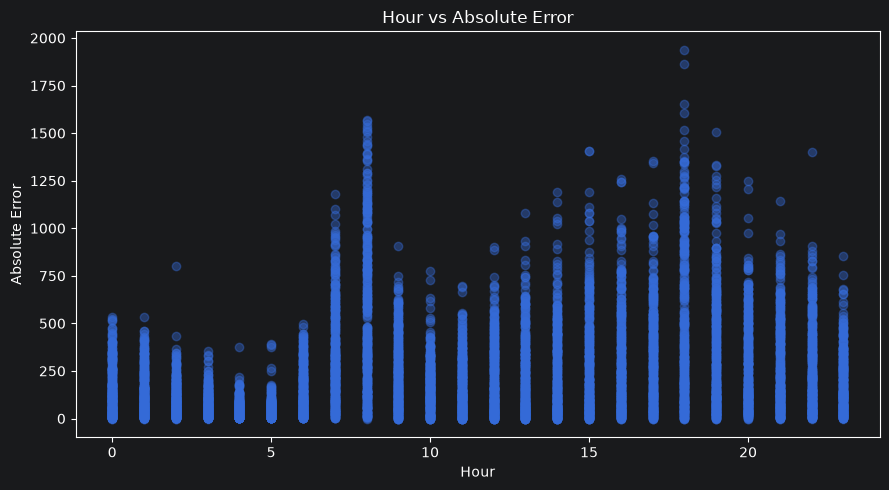

In [16]:
# plot hour against absolute error
plt.figure(figsize=(9, 5))

plt.scatter(bike_data["hour"],absolute_errors,alpha=0.4)

plt.title("Hour vs Absolute Error")
plt.xlabel("Hour")
plt.ylabel("Absolute Error")
plt.tight_layout()
plt.show()

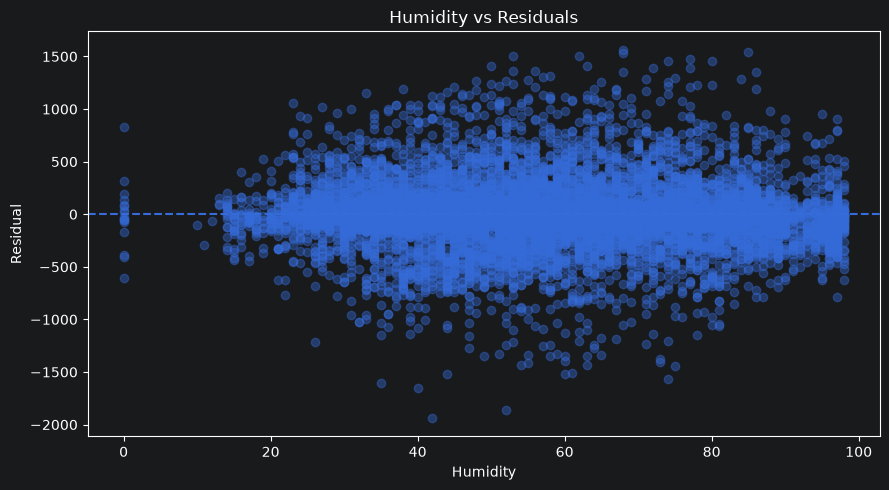

In [17]:
# plot humidity against residuals

plt.figure(figsize=(9, 5))

plt.scatter(bike_data["humidity"],residuals,alpha=0.4)

plt.axhline(y=0,linestyle="--")

plt.title("Humidity vs Residuals")
plt.xlabel("Humidity")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

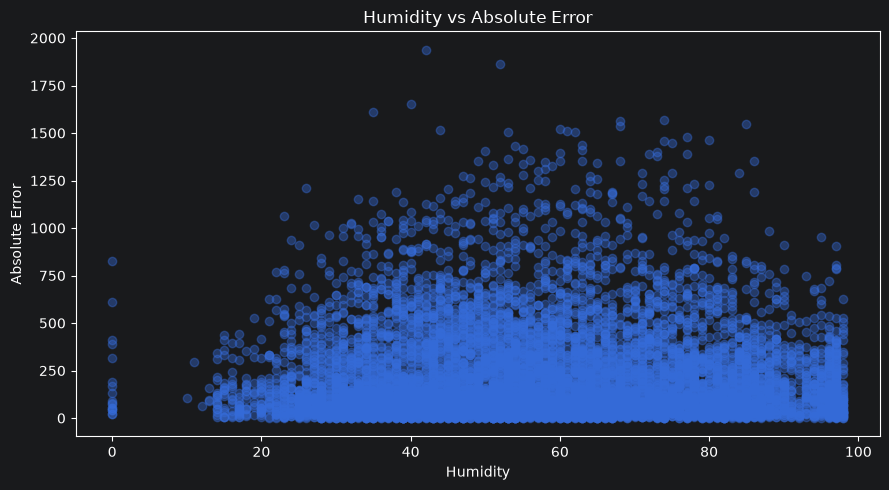

In [18]:
# plot humidity against absolute error
plt.figure(figsize=(9, 5))

plt.scatter(bike_data["humidity"],absolute_errors,alpha=0.4)

plt.title("Humidity vs Absolute Error")
plt.xlabel("Humidity")
plt.ylabel("Absolute Error")
plt.tight_layout()
plt.show()

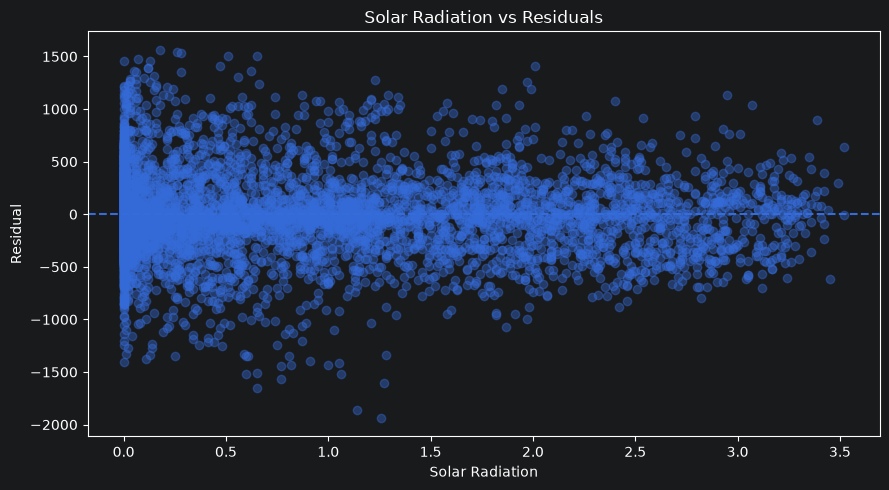

In [19]:
# plot solar radiation against residuals
plt.figure(figsize=(9, 5))

plt.scatter(bike_data["solar_radiation"],residuals,alpha=0.4)

plt.axhline(y=0,linestyle="--")

plt.title("Solar Radiation vs Residuals")
plt.xlabel("Solar Radiation")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

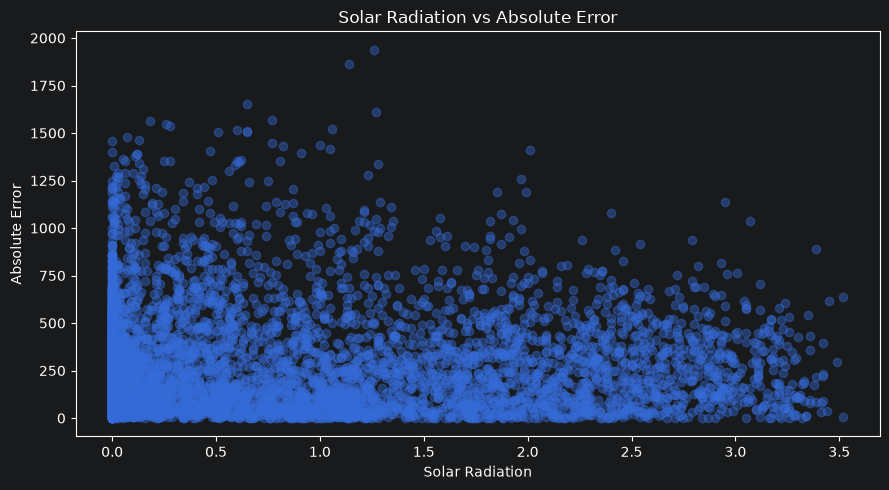

In [20]:
# plot solar radiation against absolute error
plt.figure(figsize=(9, 5))

plt.scatter(bike_data["solar_radiation"],absolute_errors,alpha=0.4)

plt.title("Solar Radiation vs Absolute Error")
plt.xlabel("Solar Radiation")
plt.ylabel("Absolute Error")
plt.tight_layout()
plt.show()

### findings

temperature has a clear effect on the prediction error

the absolute error is usually smaller at very low temperatures and becomes larger at medium and high temperatures

hour also shows a strong pattern in the errors

the largest errors appear mostly around the morning and evening rush hours especially around 8 and 18

humidity shows a weaker pattern

the errors are usually larger around medium humidity levels while very high humidity tends to have smaller errors

solar radiation also affects the error

the largest errors appear mostly when solar radiation is low

overall the errors are not randomly distributed across the features

this suggests that some conditions and time periods are harder for the model to predict

## 1.3 analysis of extreme errors

in this section i will analyze the observations with the largest prediction errors

the top 5 percent of absolute errors will be examined

In [21]:
# find the top 5 percent largest errors
error_threshold = np.quantile(absolute_errors,0.95)

error_threshold

np.float64(714.9274999999998)

In [22]:
# create a table for the largest errors
extreme_errors = bike_data.copy()

extreme_errors["predicted_count"] = forest_predictions
extreme_errors["residual"] = residuals
extreme_errors["absolute_error"] = absolute_errors

extreme_errors = extreme_errors[extreme_errors["absolute_error"] >= error_threshold]

extreme_errors = extreme_errors.sort_values("absolute_error",ascending=False)

extreme_errors.head(20)

,date,rented_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temp,solar_radiation,rainfall,snowfall,season,holiday,functioning_day,predicted_count,residual,absolute_error
5586,2018-07-21,1202,18,35.0,42,2.9,1953,20.1,1.26,0.0,0.0,Summer,No Holiday,Yes,3140.14,-1938.14,1938.14
5922,2018-08-04,1044,18,33.2,52,3.7,1986,22.0,1.14,0.0,0.0,Summer,No Holiday,Yes,2904.94,-1860.94,1860.94
6090,2018-08-11,1274,18,34.4,40,1.8,2000,18.8,0.65,0.0,0.0,Summer,No Holiday,Yes,2929.15,-1655.15,1655.15
4794,2018-06-18,746,18,29.2,35,2.7,1900,12.1,1.27,0.0,0.0,Summer,No Holiday,Yes,2354.14,-1608.14,1608.14
6440,2018-08-26,566,8,22.1,74,1.0,1479,17.2,0.77,0.0,0.0,Summer,No Holiday,Yes,2133.90,-1567.90,1567.90
6872,2018-09-13,2329,8,20.9,68,1.3,2000,14.7,0.18,0.0,0.0,Autumn,No Holiday,Yes,765.01,1563.99,1563.99
7856,2018-10-24,2108,8,8.1,85,1.2,772,5.7,0.26,0.0,0.0,Autumn,No Holiday,Yes,561.40,1546.60,1546.60
7688,2018-10-17,2202,8,9.2,68,0.2,952,3.5,0.28,0.0,0.0,Autumn,No Holiday,Yes,667.71,1534.29,1534.29
5600,2018-07-22,477,8,27.9,60,0.6,1835,19.4,1.06,0.0,0.0,Summer,No Holiday,Yes,1999.15,-1522.15,1522.15
2754,2018-03-25,768,18,14.4,44,2.7,596,2.2,0.60,0.0,0.0,Spring,No Holiday,Yes,2284.38,-1516.38,1516.38


In [23]:
# check how many extreme errors were found
print("number of extreme errors:",len(extreme_errors))

print("percent of dataset:",round(len(extreme_errors) / len(bike_data) * 100,2))

number of extreme errors: 438
percent of dataset: 5.0


In [24]:
# compare extreme errors with the full dataset

comparison = pd.DataFrame({"full data": bike_data[["rented_count","temperature","humidity","wind_speed","solar_radiation"]].mean(),
        "extreme errors": extreme_errors[["rented_count","temperature","humidity","wind_speed","solar_radiation"]].mean()})

comparison.round(2)

,full data,extreme errors
rented_count,704.60,1581.26
temperature,12.88,20.79
humidity,58.23,57.56
wind_speed,1.72,1.87
solar_radiation,0.57,0.67


In [25]:
# check which hours appear most in extreme errors
extreme_errors["hour"].value_counts().sort_index()

hour
2       1
7      32
8     111
9       3
10      2
12      3
13      8
14     14
15     24
16     30
17     25
18    101
19     40
20     14
21     17
22     11
23      2
Name: count, dtype: int64

In [26]:
# check extreme errors by season
extreme_errors["season"].value_counts()

season
Summer    200
Autumn    129
Spring    109
Name: count, dtype: int64

In [27]:
# check extreme errors by functioning day
extreme_errors["functioning_day"].value_counts()

functioning_day
Yes    437
No       1
Name: count, dtype: int64

### findings

the top 5 percent largest absolute errors start at about 714.93

there are 438 observations in this group which is exactly 5 percent of the dataset

the average rented count in the extreme error group is much higher than in the full dataset

extreme errors appear mainly during high demand periods

hours 8 and 18 appear much more often than other hours

most extreme errors appear in summer and autumn

almost all extreme errors happen on functioning days

the weather values in these rows do not look obviously incorrect

this suggests that the largest errors are mostly related to model limitations and unusual demand patterns rather than clear data quality problems

the model seems to have more difficulty during busy periods where bike demand changes quickly
### possible causes

there is no clear evidence that the largest errors are caused by bad data

the main cause seems to be model limitations because many errors happen during rush hours and high demand periods

some observations may also represent rare demand situations that are difficult to predict using the available features

## 1.4 statistical properties of errors
in this section i will check the main statistical properties of the prediction errors

In [28]:
# calculate error statistics
mae = mean_absolute_error(y,forest_predictions)
residual_std = residuals.std()
residual_skewness = skew(residuals)
residual_kurtosis = kurtosis(residuals)

print("mae:", round(mae, 2))
print("residual std:", round(residual_std, 2))
print("skewness:", round(residual_skewness, 3))
print("kurtosis:", round(residual_kurtosis, 3))

mae: 223.52
residual std: 331.79
skewness: 0.205
kurtosis: 3.162


### findings

the mean absolute error is 223.52

this means that the model misses the real rental count by about 224 bikes on average

the residual standard deviation is 331.79 which shows that the prediction errors have a fairly wide spread

the skewness is 0.205 which is close to zero

this suggests that the residual distribution does not have a strong directional bias

the kurtosis is 3.162 which suggests heavier tails

this means that extreme prediction errors happen more often than in a normal distribution

overall the model has no strong systematic bias but it still produces some large errors

In [29]:
# sort models by rmse
model_results_df.sort_values("rmse").round(3)

,model,mae,mse,rmse,r2
2,random forest,223.523,110089.819,331.798,0.735
1,decision tree,257.164,156969.633,396.194,0.623
0,linear regression,395.450,263810.830,513.625,0.366


### model comparison

the random forest gave the best results with the lowest mae and rmse and the highest r2

the decision tree performed better than linear regression but worse than the random forest

the linear regression had the weakest performance which suggests that the relationship between the features and bike demand is not fully linear

the tree based models were able to capture more complex and non linear patterns

the random forest also reduced some of the variance compared with a single decision tree

the linear regression is easier to interpret but its prediction performance is much weaker

the random forest is harder to interpret but gives the best overall prediction performance

for future analysis i would choose the random forest because it gives the lowest prediction error and the highest r2

the main thing i learned from this stage is that bike demand has patterns that are too complex for a simple linear model

the random forest achieved an mae of 223.52 and an r2 of 0.735

the decision tree achieved an mae of 257.16 and an r2 of 0.623

the linear regression achieved an mae of 395.45 and an r2 of 0.366

## 3 classification error analysis
for the classification task i will create a binary target called high demand
an observation will be classified as high demand when the rented bike count is above the median

In [30]:
# create classification target
rental_median = bike_data["rented_count"].median()

bike_data["high_demand"] = (bike_data["rented_count"] > rental_median).astype(int)

print("rental median:", rental_median)

bike_data["high_demand"].value_counts()

rental median: 504.5


high_demand
0    4380
1    4380
Name: count, dtype: int64

the target is based on the median so the two classes should be relatively balanced

In [31]:
# choose features for classification
classification_features = [
    "hour",
    "temperature",
    "humidity",
    "wind_speed",
    "visibility",
    "dew_point_temp",
    "solar_radiation",
    "rainfall",
    "snowfall",
    "season",
    "holiday",
    "functioning_day"
]

X_classification = bike_data[classification_features]

y_classification = bike_data["high_demand"]

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix,classification_report,precision_score,recall_score,f1_score,matthews_corrcoef,roc_auc_score,roc_curve)

In [33]:
# create classification model
classification_model = Pipeline(steps=[("preprocessor", preprocessor),("model",RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1))])

In [34]:
# get cross validated predictions
class_predictions = cross_val_predict(classification_model,X_classification,y_classification,cv=kfold)

In [35]:
# get prediction probabilities
class_probabilities = cross_val_predict(classification_model,X_classification,y_classification,cv=kfold,method="predict_proba")[:, 1]

In [36]:
bike_data["high_demand"].value_counts()

high_demand
0    4380
1    4380
Name: count, dtype: int64

## 3.1 confusion matrix analysis

in this section i will examine how the classification model performs on both classes

the confusion matrix will show correct and incorrect predictions

In [37]:
# create confusion matrix
conf_matrix = confusion_matrix(y_classification,class_predictions)

conf_matrix

array([[3976,  404],
       [ 535, 3845]])

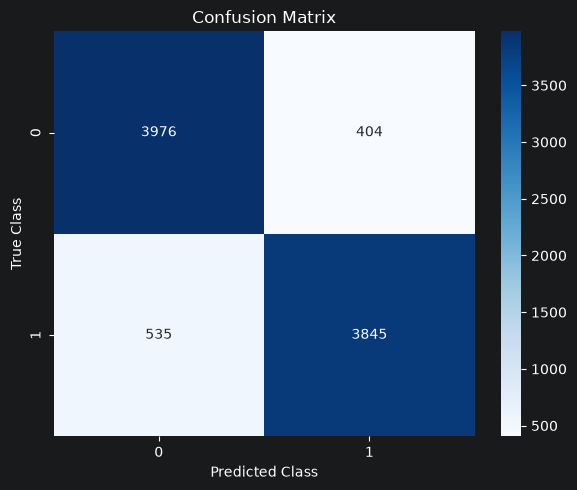

In [38]:
# plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix,annot=True,fmt="d",cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

In [39]:
# show classification report
print(classification_report(y_classification,class_predictions))

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      4380
           1       0.90      0.88      0.89      4380

    accuracy                           0.89      8760
   macro avg       0.89      0.89      0.89      8760
weighted avg       0.89      0.89      0.89      8760



### findings

the model correctly classified most observations

there are 3976 true negatives and 3845 true positives

there are 404 false positives and 535 false negatives

false negatives are slightly more common than false positives

this means that the model sometimes misses high demand periods and classifies them as low demand

the overall accuracy is about 89 percent

the precision recall and f1 scores are also close to 0.89 for both classes

the model performs fairly well on both classes because the results are balanced

### answers to the confusion matrix questions

false negatives are slightly more important in this case

missing a real high demand period may be more problematic because it could lead to not preparing enough bikes for busy hours

the model does not show a very strong failure on one class but it makes slightly more mistakes when detecting high demand

the confusion matrix shows that the classifier is generally stable and performs similarly on both classes

## 3.2 probability based analysis
in this section i will compare the predicted probabilities of correct and incorrect predictions

this can help identify cases where the model was very confident but still wrong

In [40]:
# create probability analysis table
probability_data = pd.DataFrame({"true_class": y_classification,"predicted_class": class_predictions,"probability": class_probabilities})
probability_data["correct"] = (probability_data["true_class"]== probability_data["predicted_class"])
probability_data.head()

,true_class,predicted_class,probability,correct
0,0,0,0.00,True
1,0,0,0.02,True
2,0,0,0.00,True
3,0,0,0.00,True
4,0,0,0.00,True


In [41]:
# compare correct and incorrect predictions
probability_summary = (probability_data.groupby("correct")["probability"].agg(["count", "mean", "median", "std"]).round(3))
probability_summary

,count,mean,median,std
correct,,,,
False,939,0.493,0.46,0.251
True,7821,0.504,0.45,0.412


In [42]:
# calculate prediction confidence
probability_data["confidence"] = np.where(probability_data["predicted_class"] == 1,probability_data["probability"],1 - probability_data["probability"])

In [43]:
# compare confidence levels
confidence_summary = (probability_data.groupby("correct")["confidence"].agg(["count", "mean", "median", "std"]).round(3))
confidence_summary

,count,mean,median,std
correct,,,,
False,939,0.708,0.69,0.140
True,7821,0.895,0.94,0.119


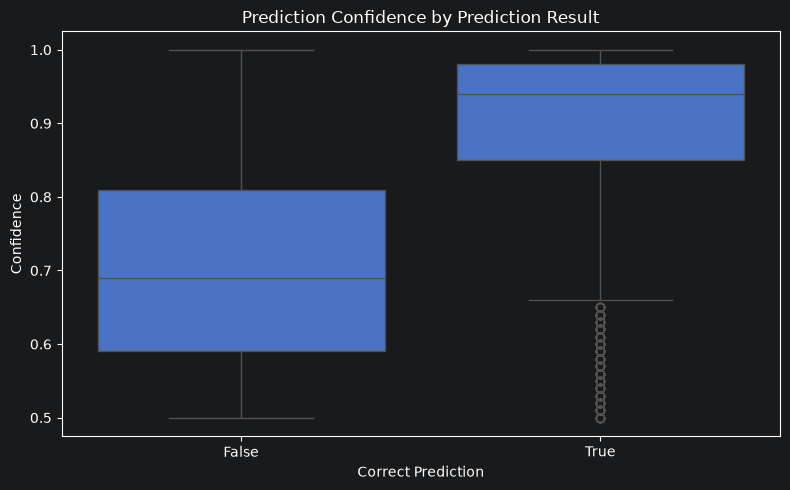

In [44]:
# plot confidence for correct and incorrect predictions
plt.figure(figsize=(8, 5))
sns.boxplot(data=probability_data,x="correct",y="confidence")
plt.title("Prediction Confidence by Prediction Result")
plt.xlabel("Correct Prediction")
plt.ylabel("Confidence")
plt.tight_layout()
plt.show()

In [45]:
# find high confidence errors
high_confidence_errors = probability_data[(probability_data["correct"] == False)& (probability_data["confidence"] >= 0.9)]
print("high confidence errors:",len(high_confidence_errors))
high_confidence_errors.head(20)

high confidence errors: 122


,true_class,predicted_class,probability,correct,confidence
18,1,0,0.09,False,0.91
19,1,0,0.10,False,0.90
37,1,0,0.06,False,0.94
91,1,0,0.05,False,0.95
113,1,0,0.04,False,0.96
114,1,0,0.05,False,0.95
115,1,0,0.07,False,0.93
186,1,0,0.05,False,0.95
207,1,0,0.09,False,0.91
258,1,0,0.08,False,0.92


### findings

correct predictions usually have higher confidence than incorrect predictions

the average confidence for correct predictions is 0.895 while for incorrect predictions it is 0.708

the median confidence is also much higher for correct predictions

there are 122 high confidence errors with confidence of at least 0.9

this means that the model is sometimes very confident even when the prediction is wrong

most predictions are reliable but some difficult cases can still produce strong incorrect confidence

many of the high confidence errors are false negatives where the model predicted low demand even though the true class was high demand

## 3.3 error as a function of features

in this section i will compare some features between correct and incorrect predictions

the goal is to find conditions where the classifier makes more mistakes

In [46]:
# create data for classification error analysis
classification_analysis = bike_data.copy()
classification_analysis["correct_prediction"] = (y_classification.values == class_predictions)

In [47]:
# check error rate by hour
hour_error_rate = (classification_analysis.groupby("hour")["correct_prediction"].apply(lambda x: 1 - x.mean()))
hour_error_rate.round(3)

hour
0     0.189
1     0.216
2     0.195
3     0.033
4     0.000
5     0.000
6     0.175
7     0.293
8     0.219
9     0.115
10    0.140
11    0.096
12    0.063
13    0.049
14    0.063
15    0.052
16    0.055
17    0.058
18    0.140
19    0.066
20    0.058
21    0.063
22    0.077
23    0.159
Name: correct_prediction, dtype: float64

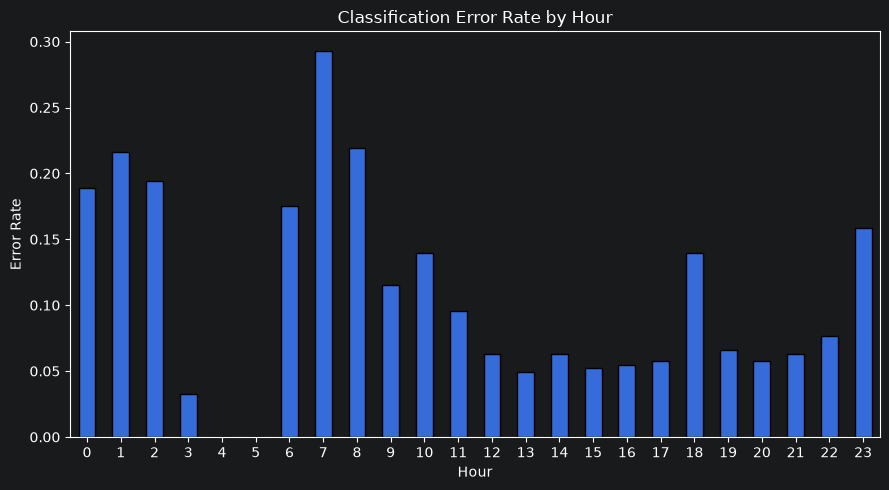

In [48]:
# plot error rate by hour
plt.figure(figsize=(9, 5))
hour_error_rate.plot(kind="bar",edgecolor="black")

plt.title("Classification Error Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Error Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

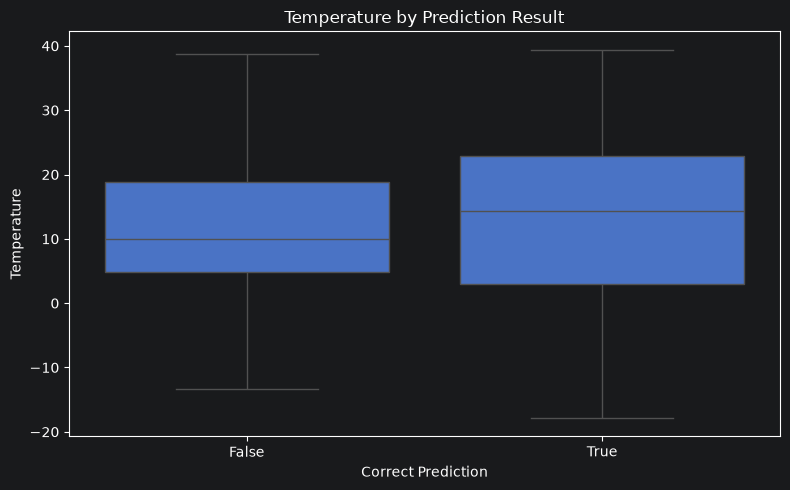

In [49]:
# compare temperature for correct and incorrect predictions
plt.figure(figsize=(8, 5))
sns.boxplot(data=classification_analysis,x="correct_prediction",y="temperature")

plt.title("Temperature by Prediction Result")
plt.xlabel("Correct Prediction")
plt.ylabel("Temperature")
plt.tight_layout()
plt.show()

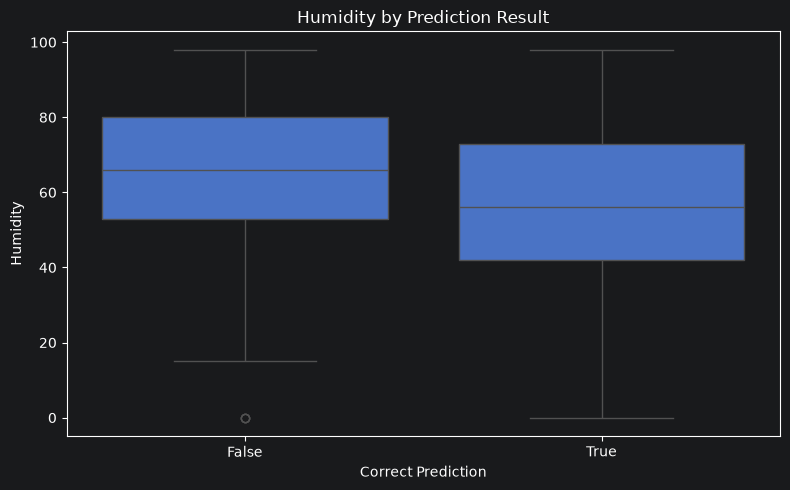

In [50]:
# compare humidity for correct and incorrect predictions
plt.figure(figsize=(8, 5))
sns.boxplot(data=classification_analysis,x="correct_prediction",y="humidity")

plt.title("Humidity by Prediction Result")
plt.xlabel("Correct Prediction")
plt.ylabel("Humidity")
plt.tight_layout()
plt.show()

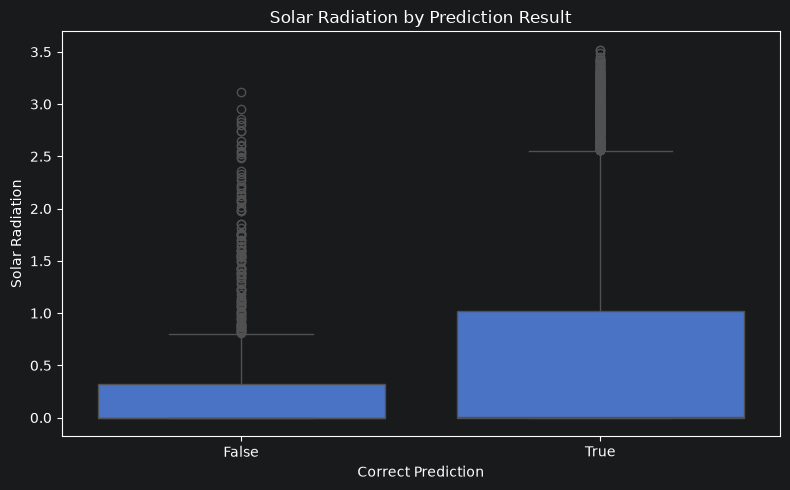

In [51]:
# compare solar radiation for correct and incorrect predictions
plt.figure(figsize=(8, 5))
sns.boxplot(data=classification_analysis,x="correct_prediction",y="solar_radiation")

plt.title("Solar Radiation by Prediction Result")
plt.xlabel("Correct Prediction")
plt.ylabel("Solar Radiation")
plt.tight_layout()
plt.show()

In [52]:
# compare average feature values
feature_error_summary = (classification_analysis.groupby("correct_prediction")[["temperature","humidity","solar_radiation"]].mean().round(2))
feature_error_summary

,temperature,humidity,solar_radiation
correct_prediction,,,
False,11.39,64.23,0.28
True,13.06,57.51,0.60


### findings

the classification error rate changes a lot between different hours

hour 7 has the highest error rate at about 29 percent

hours around the morning period also show relatively high error rates

incorrect predictions have a slightly lower average temperature than correct predictions

incorrect predictions also have higher average humidity

solar radiation is much lower on average for incorrect predictions

this suggests that the classifier has more difficulty during some early morning hours and under conditions with higher humidity and lower solar radiation

the errors are not evenly distributed across the features so some regions of the data are harder to classify

## 3.4 threshold sensitivity analysis

in this section i will check how changing the classification threshold affects model performance

the thresholds will be tested from 0.1 to 0.9

In [53]:
from sklearn.metrics import fbeta_score
# calculate metrics for different thresholds
threshold_results = []
thresholds = np.arange(0.1,1.0,0.1)
for threshold in thresholds:

    threshold_predictions = (class_probabilities >= threshold).astype(int)
    precision = precision_score(y_classification,threshold_predictions)
    recall = recall_score(y_classification,threshold_predictions)
    f1 = f1_score(y_classification,threshold_predictions)
    mcc = matthews_corrcoef(y_classification,threshold_predictions)
    threshold_results.append({"threshold": threshold,"precision": precision,"recall": recall,"f1": f1,"mcc": mcc})

threshold_results_df = pd.DataFrame(threshold_results)
threshold_results_df.round(3)

,threshold,precision,recall,f1,mcc
0,0.1,0.672,0.992,0.801,0.578
1,0.2,0.780,0.974,0.867,0.723
2,0.3,0.844,0.947,0.893,0.778
3,0.4,0.878,0.915,0.896,0.789
4,0.5,0.902,0.881,0.891,0.785
5,0.6,0.925,0.842,0.882,0.777
6,0.7,0.942,0.788,0.858,0.749
7,0.8,0.957,0.733,0.831,0.721
8,0.9,0.971,0.621,0.757,0.646


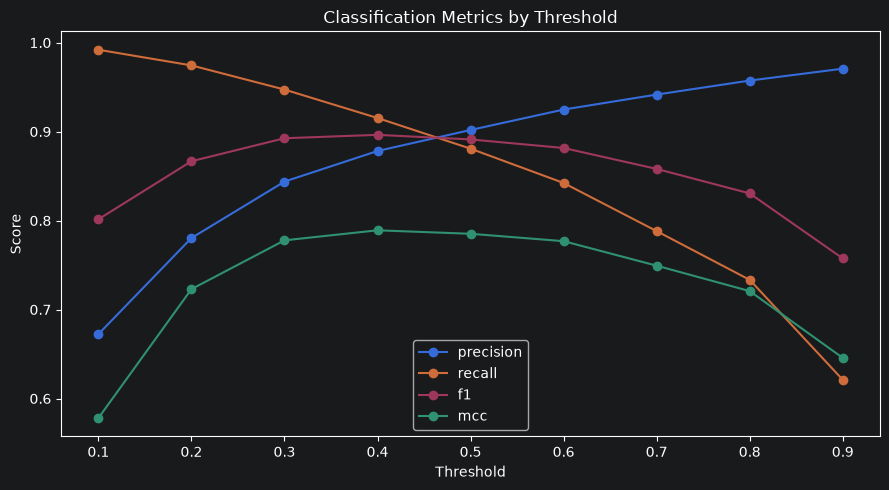

In [54]:
# plot metrics by threshold

plt.figure(figsize=(9, 5))
plt.plot(threshold_results_df["threshold"],threshold_results_df["precision"],marker="o",label="precision")
plt.plot(threshold_results_df["threshold"],threshold_results_df["recall"],marker="o",label="recall")
plt.plot(threshold_results_df["threshold"],threshold_results_df["f1"],marker="o",label="f1")
plt.plot(threshold_results_df["threshold"],threshold_results_df["mcc"],marker="o",label="mcc")

plt.title("Classification Metrics by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
# calculate auc
auc_score = roc_auc_score(y_classification,class_probabilities)

print("auc:",round(auc_score, 3))

auc: 0.959


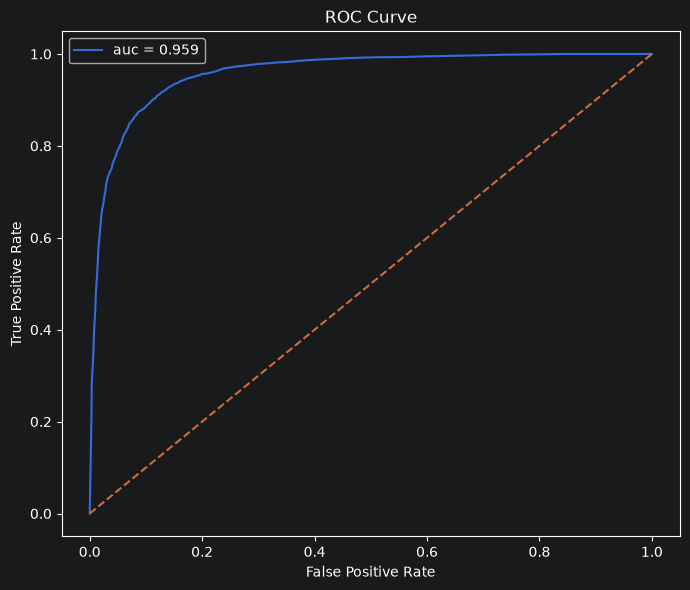

In [56]:
# make roc curve
fpr, tpr, roc_thresholds = roc_curve(y_classification,class_probabilities)

plt.figure(figsize=(7, 6))
plt.plot(fpr,tpr,label=f"auc = {auc_score:.3f}")
plt.plot([0, 1],[0, 1],linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
# calculate f beta scores
beta_values = [0.5,1,1.5,2,3]

f_beta_scores = []

for beta in beta_values:
    score = fbeta_score(y_classification,class_predictions,beta=beta)
    f_beta_scores.append(score)

f_beta_results = pd.DataFrame({"beta": beta_values,"f_beta": f_beta_scores})
f_beta_results.round(3)

,beta,f_beta
0,0.5,0.899
1,1.0,0.891
2,1.5,0.886
3,2.0,0.883
4,3.0,0.880


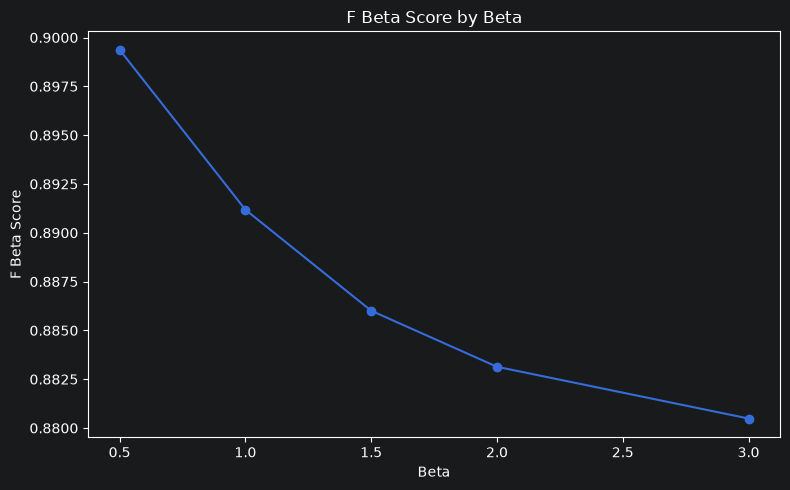

In [58]:
# plot f beta score
plt.figure(figsize=(8, 5))
plt.plot(f_beta_results["beta"],f_beta_results["f_beta"],marker="o")

plt.title("F Beta Score by Beta")
plt.xlabel("Beta")
plt.ylabel("F Beta Score")
plt.tight_layout()
plt.show()

### findings

lower thresholds give very high recall but lower precision

higher thresholds improve precision but reduce recall

the best balance appears around a threshold of 0.4 to 0.5

the f1 score is highest around threshold 0.4

the mcc score is also highest around threshold 0.4

this suggests that threshold 0.4 gives a strong and stable balance between false positives and false negatives

the auc score is 0.959 which shows that the model separates the two classes very well

the roc curve is far above the random baseline which also shows strong classification performance

the f beta score decreases slightly as beta increases

this means that the model performs a little worse when recall is given more importance

### threshold trade off

low thresholds reduce false negatives but create more false positives

high thresholds reduce false positives but create more false negatives

the middle threshold region is more stable because precision recall f1 and mcc are all relatively strong

## 3.5 discussion

the classification model performed well overall with about 89 percent accuracy

the model also achieved an auc score of 0.959 which shows strong separation between the two classes

one of the main strengths of the random forest is that it can capture non linear relationships between the features and bike demand

the model performed similarly on both classes because the dataset was balanced

one important weakness is that the model still produced more false negatives than false positives

this means that some real high demand periods were classified as low demand

the error analysis also showed that some hours are harder to classify especially around the early morning period

higher humidity and lower solar radiation were also more common in incorrect predictions

the probability analysis showed that most correct predictions have high confidence

however there were still 122 high confidence errors which means that the model can sometimes be very confident and still be wrong

changing the classification threshold showed a clear trade off between precision and recall

a threshold around 0.4 gave the best overall balance between the different metrics

for future improvement i would try adding more time based features and testing other classification models

it may also help to tune the random forest parameters and investigate the high confidence errors more closely

## 4 final reflection

the model fails most during high demand periods and around some specific hours especially in the morning and evening

the regression analysis showed larger errors when demand was high and the classification analysis also showed more mistakes in some time periods

most of the failures seem to come from model limitations and difficult demand patterns rather than clear data quality problems

the data itself looked mostly clean and the largest errors did not show obvious invalid values

the problem formulation also affects the classification results because high demand was defined using the median rental count

for future improvement i would add more time based features such as month weekday and rush hour indicators

i would also tune the model parameters and compare more models such as gradient boosting

another improvement would be to study the high confidence errors and extreme regression errors more closely

the main insight from this analysis is that bike demand is strongly affected by time and weather conditions

the models perform well overall but some periods are much harder to predict than others

error analysis was useful because it showed not only how accurate the models are but also where and why they fail